In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
df=pd.read_excel(r"C:\Users\Welcome\Downloads\ML\Contraceptive_method_dataset.xlsx")

In [3]:
df.head()

,Wife_age,Wife_ education,Husband_education,No_of_children_born,Wife_religion,Wife_Working,Husband_Occupation,Standard_of_living_index,Media_exposure,Contraceptive_method_used
0,24.0,Primary,Secondary,3.0,Scientology,No,2,High,Exposed,No
1,45.0,Uneducated,Secondary,10.0,Scientology,No,3,Very High,Exposed,No
2,43.0,Primary,Secondary,7.0,Scientology,No,3,Very High,Exposed,No
3,42.0,Secondary,Primary,9.0,Scientology,No,3,High,Exposed,No
4,36.0,Secondary,Secondary,8.0,Scientology,No,3,Low,Exposed,No


In [4]:
df.shape

(1473, 10)

In [5]:
df['Contraceptive_method_used'].unique()

array(['No', 'Yes'], dtype=object)

In [9]:
df['Contraceptive_method_used'].value_counts()

Contraceptive_method_used
Yes    844
No     629
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Wife_age                   1402 non-null   float64
 1   Wife_ education            1473 non-null   object 
 2   Husband_education          1473 non-null   object 
 3   No_of_children_born        1452 non-null   float64
 4   Wife_religion              1473 non-null   object 
 5   Wife_Working               1473 non-null   object 
 6   Husband_Occupation         1473 non-null   int64  
 7   Standard_of_living_index   1473 non-null   object 
 8   Media_exposure             1473 non-null   object 
 9   Contraceptive_method_used  1473 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 115.2+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Wife_age,1402.0,32.606277,8.274927,16.0,26.0,32.0,39.0,49.0
No_of_children_born,1452.0,3.254132,2.365212,0.0,1.0,3.0,4.0,16.0
Husband_Occupation,1473.0,2.137814,0.864857,1.0,1.0,2.0,3.0,4.0


In [12]:
df['Wife_ education'].unique()

array(['Primary', 'Uneducated', 'Secondary', 'Tertiary'], dtype=object)

In [13]:
df['Husband_education'].unique()

array(['Secondary', 'Primary', 'Tertiary', 'Uneducated'], dtype=object)

In [14]:
df['Wife_religion'].unique()

array(['Scientology', 'Non-Scientology'], dtype=object)

In [15]:
df['Wife_Working'].unique()

array(['No', 'Yes'], dtype=object)

In [16]:
df['Husband_Occupation'].unique()

array([2, 3, 1, 4])

In [17]:
df['Standard_of_living_index'].unique()

array(['High', 'Very High', 'Low', 'Very Low'], dtype=object)

In [18]:
df['Contraceptive_method_used'].unique()

array(['No', 'Yes'], dtype=object)

In [19]:
df['Media_exposure '].unique()

array(['Exposed', 'Not-Exposed'], dtype=object)

# replacing the ordinal categorical into numerical

In [20]:
df['Wife_ education'] = df['Wife_ education'].replace({'Uneducated':1, 'Primary':2, 'Secondary':3, 'Tertiary':4})

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\4205277460.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Wife_ education'] = df['Wife_ education'].replace({'Uneducated':1, 'Primary':2, 'Secondary':3, 'Tertiary':4})


In [21]:
df['Husband_education'] = df['Husband_education'].replace({'Uneducated':1, 'Primary':2, 'Secondary':3, 'Tertiary':4})

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\2583275935.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Husband_education'] = df['Husband_education'].replace({'Uneducated':1, 'Primary':2, 'Secondary':3, 'Tertiary':4})


In [22]:
df['Standard_of_living_index']=df['Standard_of_living_index'].replace({'Very Low': 1,'Low': 2,'High': 3,'Very High': 4})

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\3335203092.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Standard_of_living_index']=df['Standard_of_living_index'].replace({'Very Low': 1,'Low': 2,'High': 3,'Very High': 4})


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Wife_age                   1402 non-null   float64
 1   Wife_ education            1473 non-null   int64  
 2   Husband_education          1473 non-null   int64  
 3   No_of_children_born        1452 non-null   float64
 4   Wife_religion              1473 non-null   object 
 5   Wife_Working               1473 non-null   object 
 6   Husband_Occupation         1473 non-null   int64  
 7   Standard_of_living_index   1473 non-null   int64  
 8   Media_exposure             1473 non-null   object 
 9   Contraceptive_method_used  1473 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 115.2+ KB


# replacing the binary categorical into numerical

In [24]:
df['Wife_Working'] = df['Wife_Working'].replace({'Yes': 1, 'No': 0})

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\2649141398.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Wife_Working'] = df['Wife_Working'].replace({'Yes': 1, 'No': 0})


In [25]:
df['Contraceptive_method_used'] = df['Contraceptive_method_used'].replace({'Yes': 1, 'No': 0})

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\1837248366.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Contraceptive_method_used'] = df['Contraceptive_method_used'].replace({'Yes': 1, 'No': 0})


In [26]:
df['Media_exposure '] = df['Media_exposure '].replace({'Exposed': 1, 'Not-Exposed': 0})


C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\3587040797.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Media_exposure '] = df['Media_exposure '].replace({'Exposed': 1, 'Not-Exposed': 0})


In [27]:
df['Wife_religion'] = df['Wife_religion'].replace({'Scientology':1,'Non-Scientology':0})

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8928\1819112738.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Wife_religion'] = df['Wife_religion'].replace({'Scientology':1,'Non-Scientology':0})


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Wife_age                   1402 non-null   float64
 1   Wife_ education            1473 non-null   int64  
 2   Husband_education          1473 non-null   int64  
 3   No_of_children_born        1452 non-null   float64
 4   Wife_religion              1473 non-null   int64  
 5   Wife_Working               1473 non-null   int64  
 6   Husband_Occupation         1473 non-null   int64  
 7   Standard_of_living_index   1473 non-null   int64  
 8   Media_exposure             1473 non-null   int64  
 9   Contraceptive_method_used  1473 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 115.2 KB


# Finding null and replacing it

In [29]:
df.isna().sum()

Wife_age                     71
Wife_ education               0
Husband_education             0
No_of_children_born          21
Wife_religion                 0
Wife_Working                  0
Husband_Occupation            0
Standard_of_living_index      0
Media_exposure                0
Contraceptive_method_used     0
dtype: int64

In [30]:
df['Wife_age'].unique()

array([24., 45., 43., 42., 36., 19., 38., 21., 27., 44., 26., 48., 39.,
       37., 46., 40., 29., 31., 33., 25., 28., 47., 32., 49., 34., 20.,
       22., 30., 23., 35., 41., 17., 18., 16., nan])

In [31]:
df['Wife_age']=df['Wife_age'].fillna(df['Wife_age'].median())

In [32]:
df['Wife_age'].isna().sum()

np.int64(0)

In [33]:
df['No_of_children_born']=df['No_of_children_born'].fillna(df['No_of_children_born'].median())

In [34]:
df['No_of_children_born'].isna().sum()

np.int64(0)

In [35]:
df.isna().sum()

Wife_age                     0
Wife_ education              0
Husband_education            0
No_of_children_born          0
Wife_religion                0
Wife_Working                 0
Husband_Occupation           0
Standard_of_living_index     0
Media_exposure               0
Contraceptive_method_used    0
dtype: int64

# what factors affecting much?

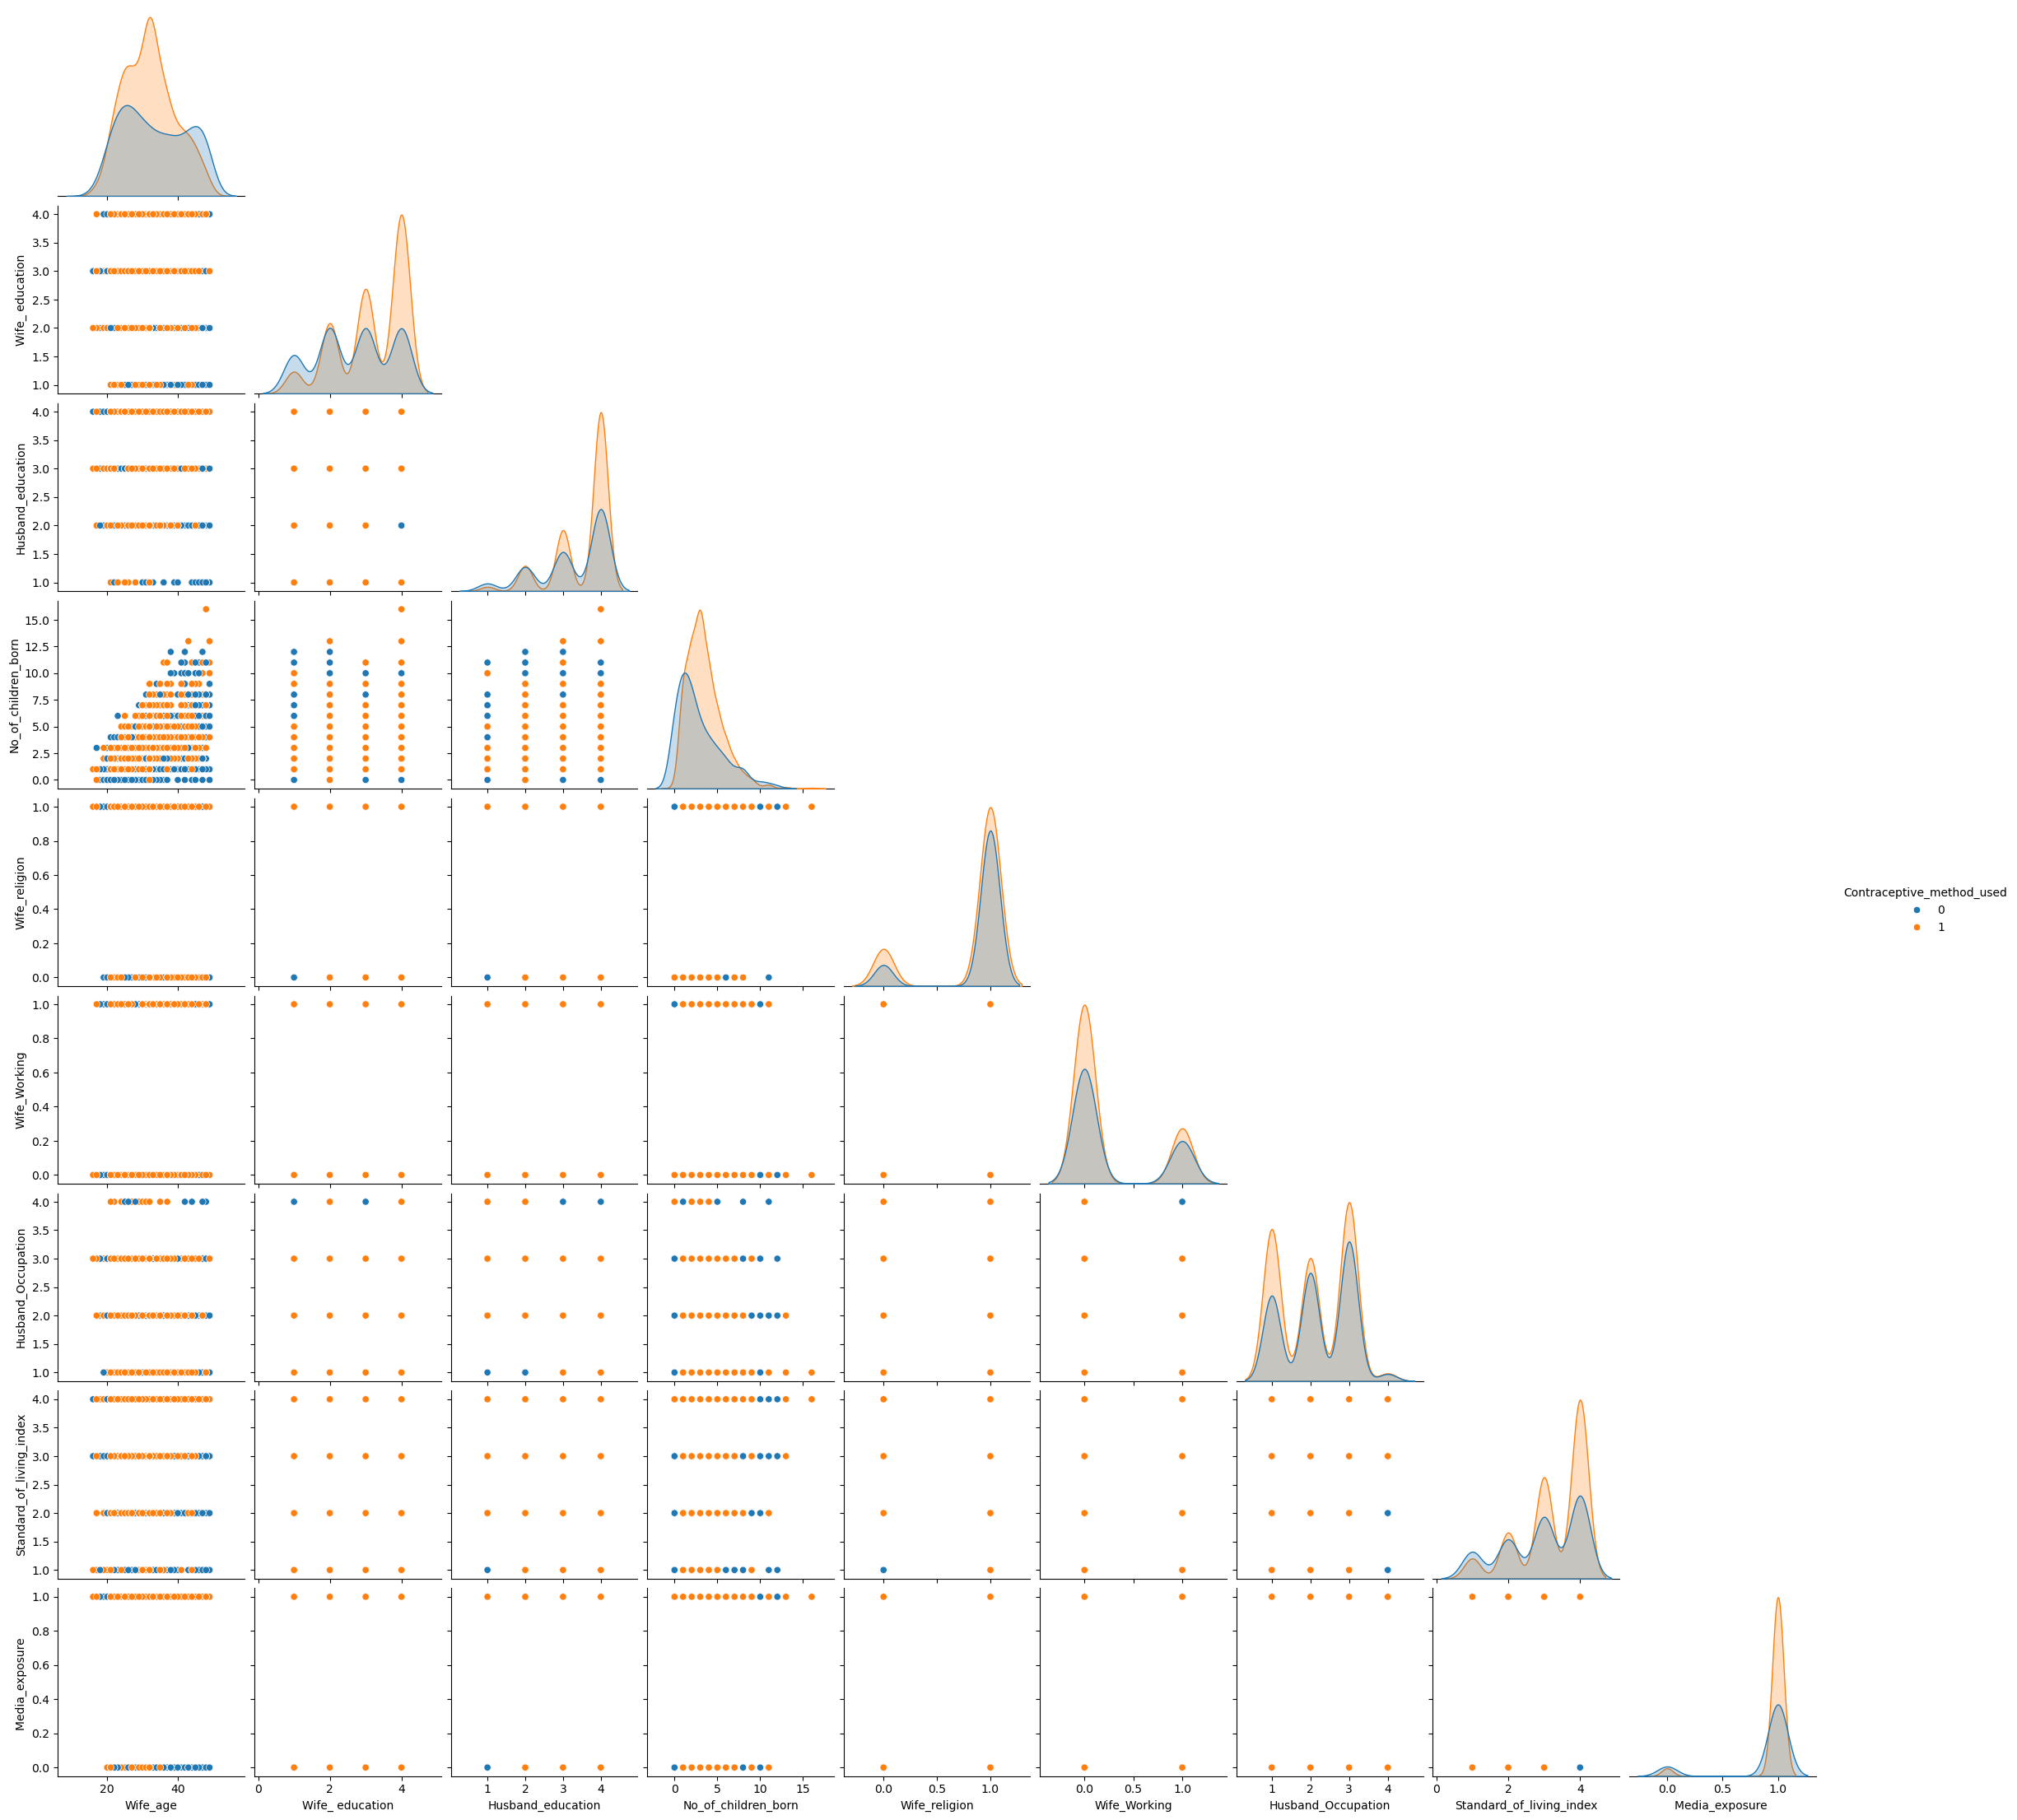

In [36]:
sns.pairplot(data=df,diag_kind='kde',hue= 'Contraceptive_method_used',corner=True)
plt.show()

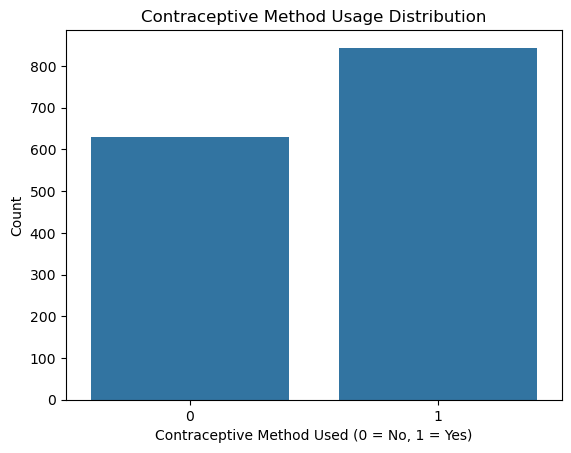

In [37]:
sns.countplot(x='Contraceptive_method_used', data=df)
plt.title("Contraceptive Method Usage Distribution")
plt.xlabel("Contraceptive Method Used (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

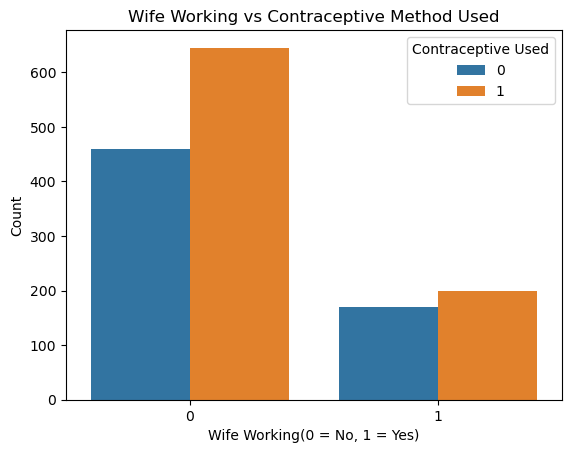

In [38]:
sns.countplot(x='Wife_Working',hue='Contraceptive_method_used',data=df)
plt.title("Wife Working vs Contraceptive Method Used")
plt.xlabel("Wife Working(0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Contraceptive Used")
plt.show()

#NON WORKING WOMEN USE CONTRACEPTIVE METHOD MORE

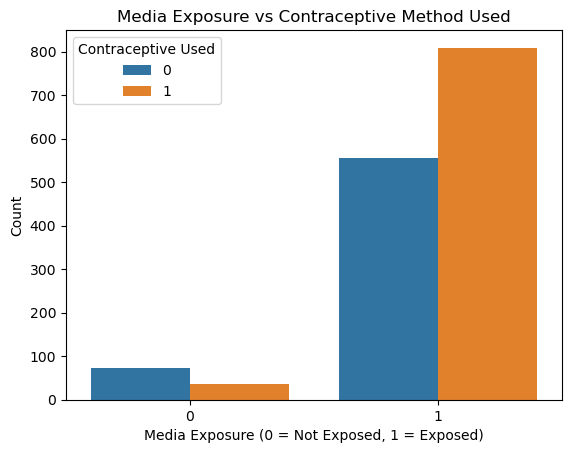

In [39]:
sns.countplot(x='Media_exposure ',hue='Contraceptive_method_used',data=df)
plt.title("Media Exposure vs Contraceptive Method Used")
plt.xlabel("Media Exposure (0 = Not Exposed, 1 = Exposed)")
plt.ylabel("Count")
plt.legend(title="Contraceptive Used")
plt.show()

#women who are exposed to media using more than non exposed ones

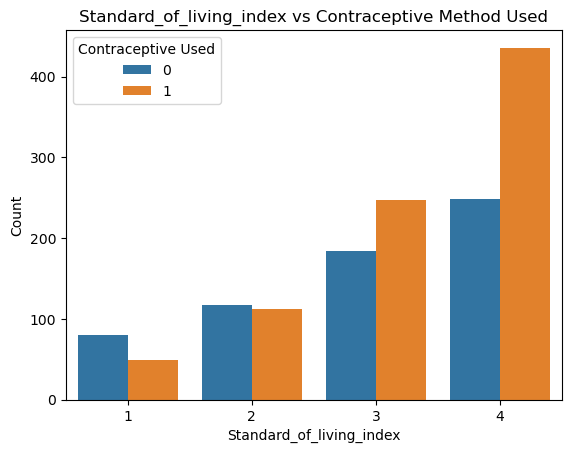

In [40]:
sns.countplot(x='Standard_of_living_index',hue='Contraceptive_method_used',data=df)
plt.title("Standard_of_living_index vs Contraceptive Method Used")
plt.xlabel("Standard_of_living_index")
plt.ylabel("Count")
plt.legend(title="Contraceptive Used")
plt.show()

# very high class women using more

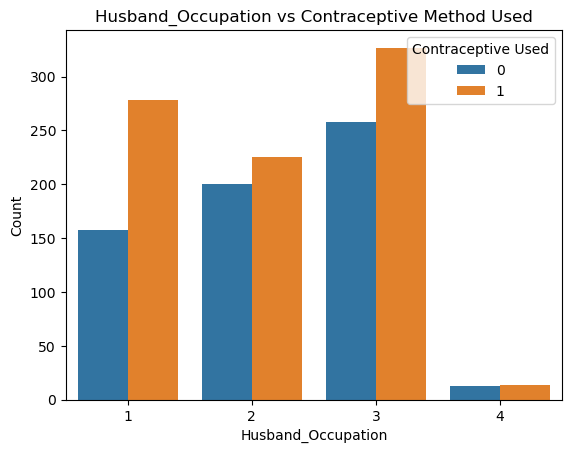

In [41]:
sns.countplot(x='Husband_Occupation',hue='Contraceptive_method_used',data=df)
plt.title("Husband_Occupation vs Contraceptive Method Used")
plt.xlabel("Husband_Occupation")
plt.ylabel("Count")
plt.legend(title="Contraceptive Used")
plt.show()

#neutral compared to other factors

In [42]:
df.columns

Index(['Wife_age', 'Wife_ education', 'Husband_education',
       'No_of_children_born', 'Wife_religion', 'Wife_Working',
       'Husband_Occupation', 'Standard_of_living_index', 'Media_exposure ',
       'Contraceptive_method_used'],
      dtype='object')

# train_test_split

In [43]:
x=df.drop('Contraceptive_method_used',axis=1)
x

,Wife_age,Wife_ education,Husband_education,No_of_children_born,Wife_religion,Wife_Working,Husband_Occupation,Standard_of_living_index,Media_exposure
0,24.0,2,3,3.0,1,0,2,3,1
1,45.0,1,3,10.0,1,0,3,4,1
2,43.0,2,3,7.0,1,0,3,4,1
3,42.0,3,2,9.0,1,0,3,3,1
4,36.0,3,3,8.0,1,0,3,2,1
...,...,...,...,...,...,...,...,...,...
1468,33.0,4,4,3.0,1,1,2,4,1
1469,33.0,4,4,3.0,1,0,1,4,1
1470,39.0,3,3,3.0,1,1,1,4,1
1471,33.0,3,3,3.0,1,1,2,2,1


In [44]:
y=df['Contraceptive_method_used']
y

0       0
1       0
2       0
3       0
4       0
       ..
1468    1
1469    1
1470    1
1471    1
1472    1
Name: Contraceptive_method_used, Length: 1473, dtype: int64

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [46]:
len(x_train)

1031

In [47]:
len(x_test)

442

In [48]:
len(y_train)

1031

In [49]:
len(y_test)

442

# Train the data

In [50]:
model=LogisticRegression()
model.fit(x_train,y_train)

C:\Users\Welcome\anaconda3\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# prediction

In [51]:
y_train_pred=model.predict(x_train)

In [52]:
y_test_pred=model.predict(x_test)

# create dataframes to compare the actual values and predicted values

In [53]:
table1=pd.DataFrame()
table1['Y_Train actual']=y_train
table1['Y_Train Predicted']=y_train_pred
table1

,Y_Train actual,Y_Train Predicted
453,1,1
99,0,1
1044,0,1
807,1,1
1400,1,1
...,...,...
715,1,1
905,1,0
1096,0,1
235,0,0


In [54]:
table2=pd.DataFrame()
table2['Y_Test actual']=y_test
table2['Y_Test Predicted']=y_test_pred
table2

,Y_Test actual,Y_Test Predicted
1126,0,1
390,0,0
824,1,1
341,0,1
1213,0,1
...,...,...
1343,1,1
1401,1,1
351,0,0
41,0,0


# Accuracy

In [55]:
model.score(x_train,y_train)

0.6692531522793405

In [56]:
model.score(x_test,y_test)

0.6877828054298643

# Confusion Matrix

In [57]:
from sklearn.metrics import confusion_matrix,classification_report

In [58]:
cm1=confusion_matrix(y_train,y_train_pred)
cm1

array([[205, 231],
       [110, 485]])

In [59]:
cm2=confusion_matrix(y_test,y_test_pred)
cm2

array([[ 94,  99],
       [ 39, 210]])

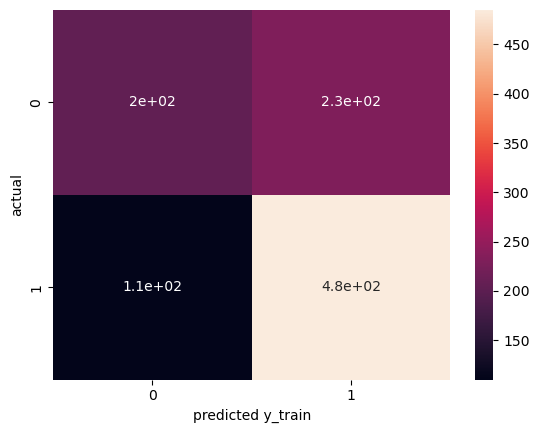

In [63]:
sns.heatmap(cm1,annot=True)
plt.xlabel('predicted y_train')
plt.ylabel('actual')
plt.show()

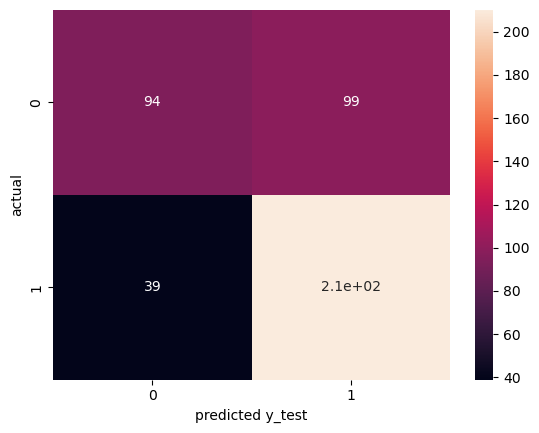

In [64]:
sns.heatmap(cm2,annot=True)
plt.xlabel('predicted y_test')
plt.ylabel('actual')
plt.show()

In [60]:
cr1=classification_report(y_train,y_train_pred)
print("classification report","\n",cr1)

classification report 
               precision    recall  f1-score   support

           0       0.65      0.47      0.55       436
           1       0.68      0.82      0.74       595

    accuracy                           0.67      1031
   macro avg       0.66      0.64      0.64      1031
weighted avg       0.67      0.67      0.66      1031



In [61]:
cr2=classification_report(y_test,y_test_pred)
print('classification report','\n',cr2)

classification report 
               precision    recall  f1-score   support

           0       0.71      0.49      0.58       193
           1       0.68      0.84      0.75       249

    accuracy                           0.69       442
   macro avg       0.69      0.67      0.66       442
weighted avg       0.69      0.69      0.68       442

